# Breast Cancer Prediction Project

Welcome to the Breast Cancer Prediction project! 🎯

In this beginner-friendly notebook, we'll walk through a step-by-step machine learning pipeline to predict whether a tumor is malignant or benign based on various features.

## 🔍 Objective

Our goal is to build a machine learning model that can accurately predict whether a tumor is **malignant (M)** or **benign (B)** based on a set of measurements.

We'll use the dataset `Cancer_Data.csv` for this purpose.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

/home/user/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 📥 Step 1: Load the Dataset

In [2]:
data=pd.read_csv('Cancer_Data.csv')

## 🔍 Step 2: Explore the Dataset

In [3]:
#print(data)

In [4]:
# Display the first 5 rows of the DataFrame
#print(data.head())

In [5]:
#To print the headers as a list
#print(data.columns.tolist())
#To print each header on a new line
#for col in df.columns:
    #print(col)

## 🧹 Step 3: Clean the Data

We'll remove any unnecessary columns and handle missing values.

In [6]:
# Drop the 'Unnamed: 32' column and 'id'
data1 = data.drop(columns=['id','Unnamed: 32'])
#print(data1)

## 📊 Step 4: Visualize the Data

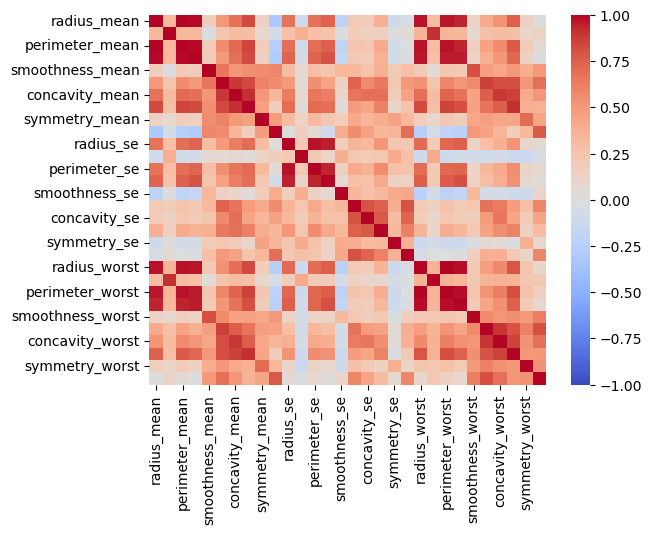

In [7]:
### Convert diagnosis column to 0 (benign) and 1 (malignant)
data1['diagnosis'] = data1['diagnosis'].replace('M', '1')
data1['diagnosis'] = data1['diagnosis'].replace('B', '0')
#print(data1)

corr = data1.corr()

# Create the heatmap
import seaborn as sns
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

## ⚙️ Step 5: Preprocess the Data

In [8]:
### Convert diagnosis column to 0 (benign) and 1 (malignant)
#data1['diagnosis'] = data1['diagnosis'].replace('M', '1')
#data1['diagnosis'] = data1['diagnosis'].replace('B', '0')
#print(data1)

### Split features and labels
X=data1.drop('diagnosis', axis=1) #features
y=data1['diagnosis']               #label
#print(features)
#print(label)

### Split into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(
    X, y, 
    test_size=0.2,       # Allocates 20% of data to the test set (a common ratio is 80/20)
    random_state=42,     # Ensures the same split is generated every time the code runs
    shuffle=True         # Shuffles the data before splitting (default behaviour)
)
#X_train.shape,X_test.shape #to know the size of array
#X_train.describe().round(3) #describe gives the no.of elements, mean std,min etc of particular column/feature
#X_test.describe().round(3)

### Scale the features. They will be in different ranges. This step is to make them into the same scale. Two methods
### 1. Normalisation(min-max scaling) -transform all features from [0,1], 2. standardisation -transform to have mean 0 and std 1.   
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#print(X_train_scaled)
print(len(X_train_scaled[0]))
ft_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
ft_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
#print(ft_test_scaled)

30


## 🤖 Step 6: Train a Machine Learning Model

In [9]:
# Use Logistic Regression
model = LogisticRegression()
model.fit(ft_train_scaled, y_train)
predictions = model.predict(ft_test_scaled)
#print(predictions)
#print(data['dignostics[ft_test_scaled.index]'])
#print(data1.iloc[ft_test_scaled.index, 0].to_numpy())
y_pred_proba = model.predict_proba(ft_test_scaled)[:, 1]
#print(y_pred_proba)

## 🧪 Step 7: Evaluate the Model

In [10]:
#accuracy score
accuracy = accuracy_score(y_test,predictions)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9736842105263158


## ✅ Conclusion

Awesome work! 🎉

You've successfully built a breast cancer prediction model using Logistic Regression. You explored the data, cleaned it, visualized it, trained a model, and evaluated its performance.

### 🚀 Next Steps
- Try different models like RandomForest or SVM
- Perform feature selection
- Tune hyperparameters for better accuracy

Like logistic regression, other classification models include Random Forest and support vector machines. These models are already defined in SciKitlearn, which is a Python module dedicated to machine learning. We have to call the particular model, then we can use different functions defined on the model.

In [11]:
# SVM model
from sklearn import svm
clf = svm.SVC()
clf.fit(ft_train_scaled, y_train)
predictions_svc=clf.predict(ft_test_scaled)
svc_pred_proba = model.predict_proba(ft_test_scaled)[:, 1]
#print(svc_pred_proba)

In [12]:
# Random forest model
from sklearn.ensemble import RandomForestClassifier
clf_RF = RandomForestClassifier()
clf_RF.fit(ft_train_scaled, y_train)
predictions_RF=clf_RF.predict(ft_test_scaled)
#RF_pred_proba = model.predict_proba(ft_test_scaled)[:, 1]

If a dataset containes large number of intependent variable or features, then we can choose features which affects the label more according to some threshold condition, this process is known as feature selection. There are many methods for feature section which given in this link https://scikit-learn.org/stable/api/sklearn.feature_selection.html#module-sklearn.feature_selection .

In [13]:
# VarianceThreshold var()=p(1-p) Feature selector that removes all low-variance features
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_prime=sel.fit_transform(X)
#print(X)
#print(len(X_prime[0]))

When we use a machine learning model, it has some parameters/weights that determine how strongly each feature depends on the label. It is just like the coefficient of each indipendent parameters. Simple case y=mx+c, here y is the label or dependent variable or target, x is the feature or independent variable, and m and c are parameters of model. Model parameters are determined from data by fitting during the time of training. Whereas a hyperparameter is a value that is set before training a machine learning model and controls how the model learns from data. It will be constant during training, or it can be defined as A configuration setting chosen before training that controls how a machine learning model learns, but is not itself learned from data. 

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# defining the hyperparameters of the model
param_distributions = {
    'n_estimators': randint(10, 200),
    'max_depth': randint(3, 20),
    'criterion': ['gini', 'entropy', 'log_loss']
}

# 3. Instantiate RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled (e.g., 20)
# cv: Number of cross-validation folds (e.g., 5)
# random_state: For reproducibility
random_search = RandomizedSearchCV(
    estimator=clf_RF,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    random_state=42,
    n_jobs=-1 # Use all processors
)
random_search.fit(X, y)
random_search.best_estimator_
#y_pred = random_search.predict(X)
y_pred = random_search.best_estimator_.predict(X)
y_proba = random_search.predict_proba(X)
#print(y_pred)
print(y_proba)
# each row gives [Probability of class 0, Probability of class 1] for each data point. 

[[0.01724138 0.98275862]
 [0.01724138 0.98275862]
 [0.         1.        ]
 ...
 [0.02586207 0.97413793]
 [0.         1.        ]
 [1.         0.        ]]
